In [78]:
# importing the libraries

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline   

In [79]:
# loading the dataset

df = pd.read_csv("airline_ticket_prices_dataset.csv")
df.sample(5)   

,Ticket_ID,Airline,Origin,Destination,Distance_km,Class,Days_Before_Departure,Price_USD
167,168,Qatar Airways,Istanbul,Mumbai,10760,Economy,32,2052.97
31,32,Lufthansa,Dubai,New York,1682,First,83,644.19
131,132,Etihad,Paris,Cairo,1602,Business,19,824.72
49,50,Emirates,Riyadh,New York,3696,Economy,6,907.58
137,138,Lufthansa,Riyadh,Doha,7826,First,24,5264.14


In [80]:
# statistical summary of the data

df.describe()    

,Ticket_ID,Distance_km,Days_Before_Departure,Price_USD
count,250.000000,250.000000,250.000000,250.000000
mean,125.500000,5999.952000,59.024000,2006.059760
std,72.312977,3401.695261,33.736628,1675.067217
min,1.000000,336.000000,1.000000,106.070000
25%,63.250000,2991.750000,31.250000,818.665000
50%,125.500000,6132.500000,60.500000,1531.235000
75%,187.750000,8832.750000,86.750000,2590.357500
max,250.000000,11903.000000,118.000000,8852.690000


     Ticket_ID  Distance_km  Days_Before_Departure  Price_USD
188        189          543                     54     425.98
209        210        11384                     11    2472.36
63          64         6533                     37    4045.74


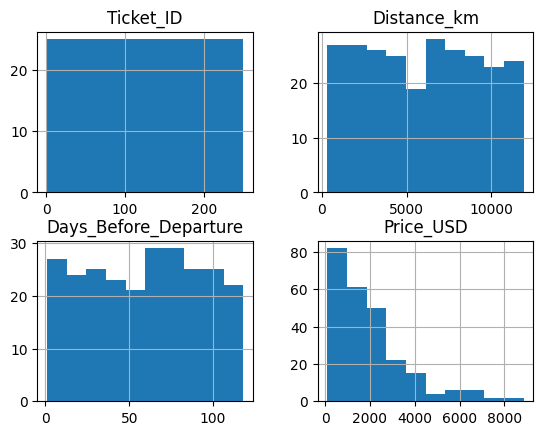

In [81]:
# visualizing the features 

cdf = df[['Ticket_ID','Distance_km','Days_Before_Departure','Price_USD']]
print(cdf.sample(3))
cdf.hist()  
plt.show()    

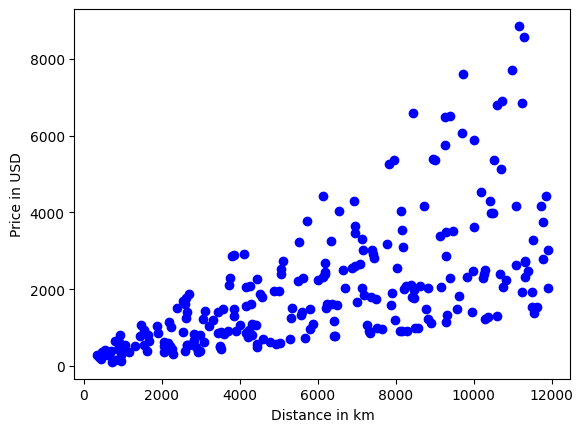

In [82]:
plt.scatter(cdf.Distance_km, cdf.Price_USD,  color='blue')
plt.xlabel("Distance in km")
plt.ylabel("Price in USD")
plt.show()   

In [83]:
# checking for missing values
df.isnull().sum()

Ticket_ID                0
Airline                  0
Origin                   0
Destination              0
Distance_km              0
Class                    0
Days_Before_Departure    0
Price_USD                0
dtype: int64

In [84]:
# defining the input and output (X and Y)

X = df[['Distance_km']]   # double brackets because sklearn expects 2D
Y = df['Price_USD']


In [85]:
# splitting the dataset into test and train
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


In [86]:
# training the model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

In [87]:
# this is what the Model Learned ...

print("Slope     :", model.coef_[0])
print("Intercept :", model.intercept_)

# the formula :  Price_USD  =  Slope × Distance_km  +  Intercept 

Slope     : 0.3137374536625057
Intercept : 118.66062927200869


In [88]:
# making predictions 
Y_pred = model.predict(X_test)

In [89]:
# evaluation 
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

print("R2 Score :", r2_score(Y_test, Y_pred))
print("MAE      :", mean_absolute_error(Y_test, Y_pred))

R2 Score : 0.3298554833210203
MAE      : 1052.93870653647


R2 Score : 0.3298554833210203
MAE      : 1052.93870653647
            
it means: 


Price is decided 33% by Distance ✅
Price is decided 67% by other things ❌ (Class, Airline etc.)

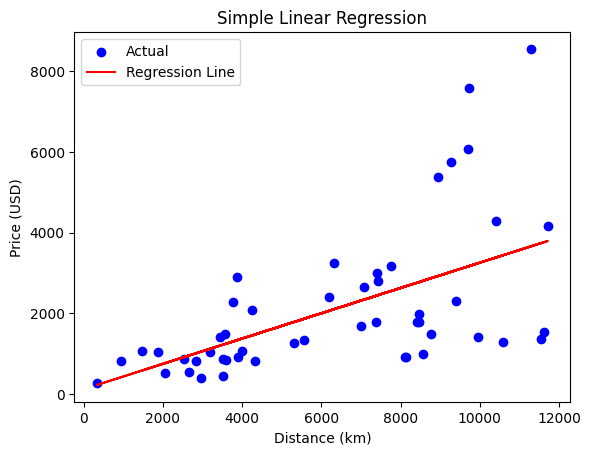

In [90]:
#  Plotting the Regression Line

plt.scatter(X_test, Y_test, color='blue', label='Actual')
plt.plot(X_test, Y_pred, color='red', label='Regression Line')
plt.xlabel("Distance (km)")
plt.ylabel("Price (USD)")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()

# Blue dots = actual prices, Red line = what our model predicted.      
